# BSDS500 Segmentation with Belief Propagation

This notebook runs the improved BP segmentation pipeline and explains the saved outputs.

Outputs are saved under `results/segmentation/bsds500/`:
- `metrics.csv`: per-image IoU/accuracy/runtime/iterations
- `summary.json`: dataset averages and std
- `plots/`: qualitative examples, histograms, convergence curves
            


In [ ]:
from pathlib import Path
import json
import matplotlib.pyplot as plt
import numpy as np

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
if not (PROJECT_ROOT / 'datasets').exists():
    PROJECT_ROOT = Path('/mnt/D/mva_P2/GRM/belief_propagation')

import sys
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from datasets.bsds500_loader import load_bsds500_dataset
from experiments.segmentation_bsds500 import run_experiment
            


Using BSDS500 path: /mnt/D/mva_P2/GRM/belief_propagation/data/BSDS500
Loaded 4 samples


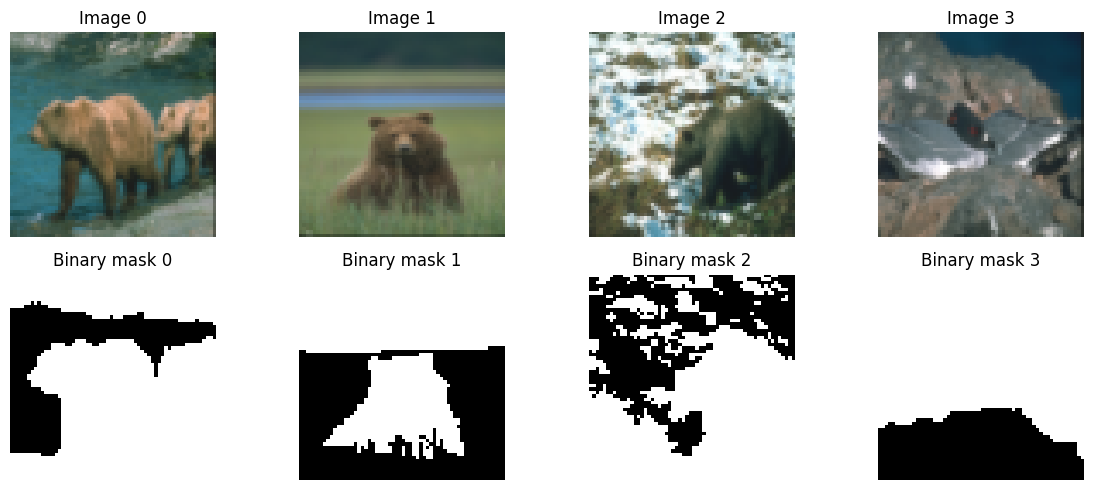

In [ ]:
# Auto-detect BSDS500 root in common locations.
candidates = [
    PROJECT_ROOT / 'data' / 'BSDS500',
    PROJECT_ROOT.parent / 'data' / 'BSDS500',
    Path('/tmp/bp_demo_data/BSDS500'),
]

def looks_like_bsds(path: Path) -> bool:
    return (path / 'data' / 'images').exists() or (path / 'images').exists()

bsds_path = next((p for p in candidates if looks_like_bsds(p)), None)
if bsds_path is None:
    raise FileNotFoundError('BSDS500 not found. Set bsds_path manually to the dataset root.')

print(f'Using BSDS500 path: {bsds_path}')
images, masks = load_bsds500_dataset(bsds_path, max_images=4, resize=(60, 60))
print(f'Loaded {len(images)} samples')

n = min(4, len(images))
fig, axes = plt.subplots(2, n, figsize=(3*n, 5))
if n == 1:
    axes = np.array([[axes[0]], [axes[1]]])
for i in range(n):
    if images[i].ndim == 2:
        axes[0, i].imshow(images[i], cmap='gray')
    else:
        axes[0, i].imshow(np.clip(images[i], 0.0, 1.0))
    axes[0, i].set_title(f'Image {i}')
    axes[0, i].axis('off')
    axes[1, i].imshow(masks[i], cmap='gray', vmin=0, vmax=1)
    axes[1, i].set_title(f'Binary mask {i}')
    axes[1, i].axis('off')
plt.tight_layout()
            


In [ ]:
# Run the experiment.
import argparse

RESULTS_DIR = PROJECT_ROOT / 'results' / 'segmentation' / 'bsds500'
args = argparse.Namespace(
    data_path=str(bsds_path),
    max_images=20,
    resize=[60, 60],
    max_iters=50,
    tol=1e-3,
    damping=0.5,
    lambda_=2.0,
    seed=0,
    results_dir=str(RESULTS_DIR),
    use_gt_unary=True,
)
summary = run_experiment(args)
summary
            


[1/20] IoU=0.8490 Acc=0.8697 Runtime=20.36s Iter=50 Converged=False
[2/20] IoU=0.9066 Acc=0.9422 Runtime=21.04s Iter=50 Converged=False
[3/20] IoU=0.8704 Acc=0.9142 Runtime=11.42s Iter=24 Converged=True
[4/20] IoU=0.7183 Acc=0.7183 Runtime=7.89s Iter=16 Converged=True
[5/20] IoU=0.7436 Acc=0.7456 Runtime=13.21s Iter=28 Converged=True
[6/20] IoU=0.7695 Acc=0.9811 Runtime=15.49s Iter=37 Converged=True
[7/20] IoU=0.8453 Acc=0.9767 Runtime=13.55s Iter=33 Converged=True
[8/20] IoU=0.6566 Acc=0.6769 Runtime=20.93s Iter=50 Converged=False
[9/20] IoU=0.8549 Acc=0.9358 Runtime=22.41s Iter=50 Converged=False
[10/20] IoU=0.6839 Acc=0.6839 Runtime=7.82s Iter=16 Converged=True
[11/20] IoU=0.5130 Acc=0.8392 Runtime=22.93s Iter=50 Converged=False
[12/20] IoU=0.7206 Acc=0.8733 Runtime=21.14s Iter=50 Converged=False
[13/20] IoU=0.8142 Acc=0.8517 Runtime=21.22s Iter=50 Converged=False
[14/20] IoU=0.9364 Acc=0.9581 Runtime=25.34s Iter=50 Converged=False
[15/20] IoU=0.9332 Acc=0.9825 Runtime=9.94s Iter=17

{'num_images': 20,
 'mean_iou': 0.7867689291692006,
 'std_iou': 0.12726272348087905,
 'mean_accuracy': 0.8635138888888889,
 'std_accuracy': 0.10239562116137921,
 'mean_runtime_sec': 16.465583976400374,
 'mean_iterations': 37.45,
 'convergence_rate': 0.45,
 'config': {'data_path': '/mnt/D/mva_P2/GRM/belief_propagation/data/BSDS500',
  'max_images': 20,
  'resize': [60, 60],
  'max_iters': 50,
  'tol': 0.001,
  'damping': 0.5,
  'lambda': 2.0,
  'use_gt_unary': True,
  'seed': 0}}

In [ ]:
# Load and interpret summary.
summary_path = RESULTS_DIR / 'summary.json'
with summary_path.open() as f:
    summary = json.load(f)

print('BSDS500 summary:')
print(json.dumps(summary, indent=2))
print('Interpretation:')
print(f"- Mean IoU: {summary['mean_iou']:.3f} (higher is better)")
print(f"- Std IoU: {summary['std_iou']:.3f} (lower means more stable across images)")
print(f"- Mean accuracy: {summary['mean_accuracy']:.3f}")
print(f"- Convergence rate: {summary['convergence_rate']:.3f}")
            


BSDS500 summary:
{
  "num_images": 20,
  "mean_iou": 0.7867689291692006,
  "std_iou": 0.12726272348087905,
  "mean_accuracy": 0.8635138888888889,
  "std_accuracy": 0.10239562116137921,
  "mean_runtime_sec": 16.465583976400374,
  "mean_iterations": 37.45,
  "convergence_rate": 0.45,
  "config": {
    "data_path": "/mnt/D/mva_P2/GRM/belief_propagation/data/BSDS500",
    "max_images": 20,
    "resize": [
      60,
      60
    ],
    "max_iters": 50,
    "tol": 0.001,
    "damping": 0.5,
    "lambda": 2.0,
    "use_gt_unary": true,
    "seed": 0
  }
}
Interpretation:
- Mean IoU: 0.787 (higher is better)
- Std IoU: 0.127 (lower means more stable across images)
- Mean accuracy: 0.864
- Convergence rate: 0.450


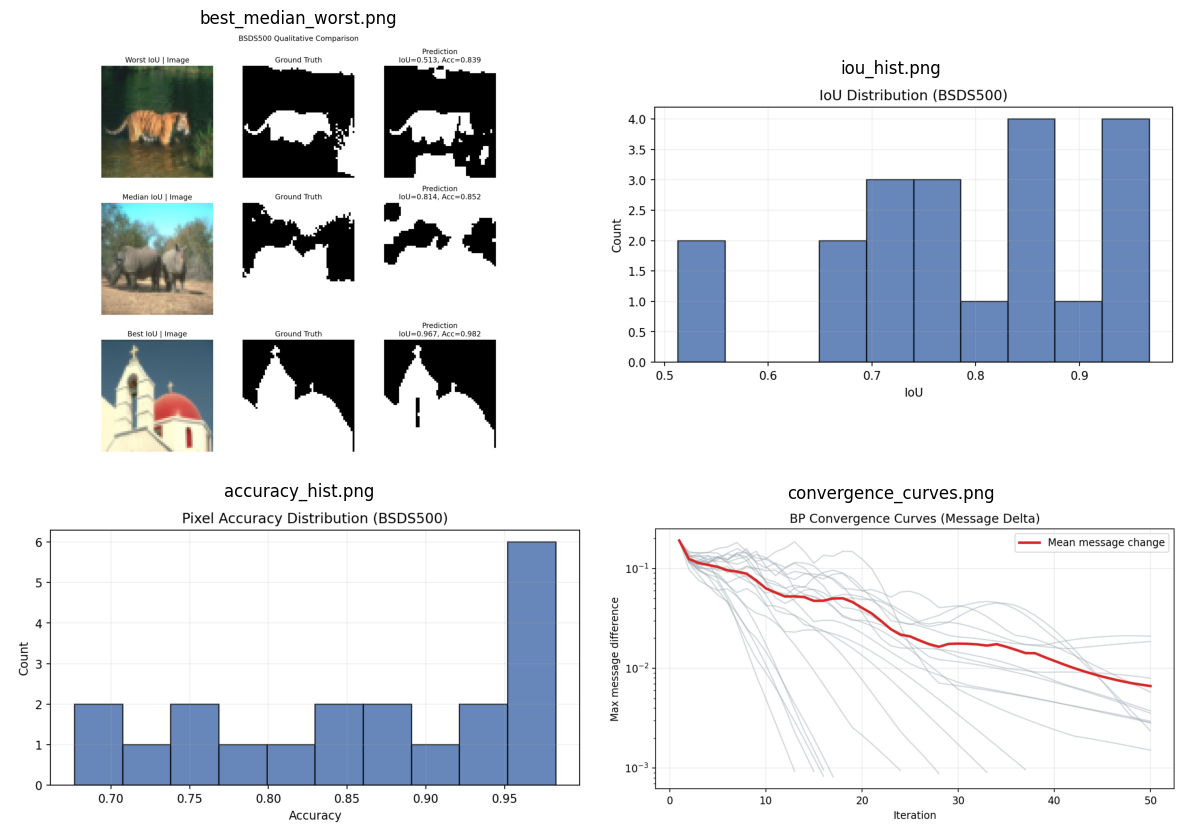

In [ ]:
# Show key plots.
plot_paths = [
    RESULTS_DIR / 'plots' / 'best_median_worst.png',
    RESULTS_DIR / 'plots' / 'iou_hist.png',
    RESULTS_DIR / 'plots' / 'accuracy_hist.png',
    RESULTS_DIR / 'plots' / 'convergence_curves.png',
]

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, path in zip(axes.ravel(), plot_paths):
    if path.exists():
        ax.imshow(plt.imread(path))
        ax.set_title(path.name)
    else:
        ax.text(0.5, 0.5, f'Missing: {path.name}', ha='center', va='center')
    ax.axis('off')
plt.tight_layout()
            


## Tree-Reweighted Belief Propagation (TRW)

This section runs TRW as a drop-in alternative to BP and compares:
- IoU (BP vs TRW)
- accuracy (BP vs TRW)
- convergence curves (fraction converged vs iteration)
            


In [ ]:
import argparse
from experiments.segmentation_bsds500_trw import run_experiment as run_trw_experiment

TRW_ARGS = argparse.Namespace(
    data_path=str(bsds_path),
    max_images=20,
    resize=[60, 60],
    max_iters=50,
    tol=1e-3,
    damping=0.5,
    lambda_=2.0,
    seed=0,
    results_dir=str(RESULTS_DIR),
    use_gt_unary=True,
)
trw_summary = run_trw_experiment(TRW_ARGS)
trw_summary
            


In [ ]:
import csv

bp_csv = RESULTS_DIR / 'metrics.csv'
trw_csv = RESULTS_DIR / 'bsds500_trw_metrics.csv'

def load_metrics(path):
    rows = []
    with path.open() as f:
        for row in csv.DictReader(f):
            rows.append({k: float(v) for k, v in row.items()})
    return rows

bp_rows = load_metrics(bp_csv)
trw_rows = load_metrics(trw_csv)

bp_iou = np.array([r['iou'] for r in bp_rows])
trw_iou = np.array([r['iou'] for r in trw_rows])
bp_acc = np.array([r['accuracy'] for r in bp_rows])
trw_acc = np.array([r['accuracy'] for r in trw_rows])

bp_iter = np.array([r['iterations'] for r in bp_rows])
trw_iter = np.array([r['iterations'] for r in trw_rows])
bp_conv = np.array([r['converged'] for r in bp_rows])
trw_conv = np.array([r['converged'] for r in trw_rows])

max_iter = int(max(bp_iter.max(), trw_iter.max()))
ts = np.arange(1, max_iter + 1)
bp_curve = [np.mean((bp_conv > 0.5) & (bp_iter <= t)) for t in ts]
trw_curve = [np.mean((trw_conv > 0.5) & (trw_iter <= t)) for t in ts]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].bar(['BP', 'TRW'], [bp_iou.mean(), trw_iou.mean()], color=['#4C72B0', '#6A3D9A'])
axes[0].set_title('Mean IoU')
axes[0].set_ylim(0, 1)

axes[1].bar(['BP', 'TRW'], [bp_acc.mean(), trw_acc.mean()], color=['#55A868', '#C44E52'])
axes[1].set_title('Mean Accuracy')
axes[1].set_ylim(0, 1)

axes[2].plot(ts, bp_curve, label='BP', color='#4C72B0')
axes[2].plot(ts, trw_curve, label='TRW', color='#6A3D9A')
axes[2].set_title('Convergence Curve')
axes[2].set_xlabel('Iteration threshold')
axes[2].set_ylabel('Fraction converged')
axes[2].set_ylim(0, 1)
axes[2].grid(alpha=0.2)
axes[2].legend()

plt.tight_layout()

print(f'BP mean IoU={bp_iou.mean():.4f}, TRW mean IoU={trw_iou.mean():.4f}')
print(f'BP mean Acc={bp_acc.mean():.4f}, TRW mean Acc={trw_acc.mean():.4f}')
            
